# Retrieval Model Inference — Endpoint

**Model:** `tern_retr_v1` (training-run/71) — 300 epochs, batch 4096, lr 0.002, adam  
**Endpoint:** Cloud Run (native TF Serving REST API)  
**Inputs:** `customer_id, date, cust_value, cs_last_purch, cs_orders, cs_unique_skus, history[50]`  
**Outputs:** `product_ids[150], scores[150]`

In [1]:
import warnings
warnings.filterwarnings('ignore', message='BigQuery Storage module not found')

import subprocess, os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from google.cloud import bigquery
from IPython.display import display, HTML

# ── Configuration ──────────────────────────────────────────────────────
ENDPOINT_URL = 'https://ternopil-tern-retr-v1-serving-3dmqemfmxq-ez.a.run.app'
MODEL_NAME   = 'recommender'
PREDICT_URL  = f'{ENDPOINT_URL}/v1/models/{MODEL_NAME}:predict'

GCP_PROJECT = 'b2b-recs'
BQ_TEST     = f'{GCP_PROJECT}.raw_data.ternopil_test_v4'
BQ_TRAIN    = f'{GCP_PROJECT}.raw_data.ternopil_train_v4'
client      = bigquery.Client(project=GCP_PROJECT)

# GCS path for training run 71 artifacts (vocabs, metrics)
GCS_MODEL_PATH = 'gs://b2b-recs-training-artifacts/tr-71-20260306-144623/pushed_model/1772817394'

HISTORY_LEN = 50
BATCH_SIZE  = 64           # native TF Serving max_batch_size limit

# Training metrics from run 71 (300 epochs, batch_size=4096, lr=0.002, adam)
TRAINING_RECALL = {'R@5': 0.6218, 'R@10': 0.6549, 'R@50': 0.7033, 'R@100': 0.7213}

# Products to suppress from visual recommendations (noisy/dominant items)
SUPPRESS_NAMES = {
    'ARO ЦУКОР 50КГ',
    'MPRO ПАКЕТ ВЕЛ 51МКМ 45*74',
}

# ── Helpers ─────────────────────────────────────────────────────────────
def pad_history(hist, max_len=HISTORY_LEN):
    """Pad/truncate purchase history to fixed length, 0-padded.
    Converts numpy int64 → Python int for JSON serialization."""
    arr = [int(x) for x in hist] if hist is not None else []
    arr = arr[:max_len]
    return arr + [0] * (max_len - len(arr))

def build_instances(df):
    """Convert DataFrame rows to endpoint-compatible JSON instances."""
    instances = []
    for _, row in df.iterrows():
        instances.append({
            'customer_id':  int(row['customer_id']),
            'date':         int(row['date_unix']),
            'cust_value':   float(row['cust_value']),
            'cs_last_purch': int(row['days_since_last_purchase']),
            'cs_orders':    int(row['cust_order_days_60d']),
            'cs_unique_skus': int(row['cust_unique_products_60d']),
            'history':      pad_history(row['purchase_history']),
        })
    return instances

def predict(instances):
    """Call endpoint with automatic batching.
    Returns (product_ids, scores) as numpy arrays."""
    all_pids, all_scores = [], []
    for i in range(0, len(instances), BATCH_SIZE):
        batch = instances[i:i + BATCH_SIZE]
        t0 = time.time()
        resp = requests.post(PREDICT_URL, json={'instances': batch}, timeout=120)
        resp.raise_for_status()
        dt = time.time() - t0
        preds = resp.json()['predictions']
        for p in preds:
            all_pids.append(p['product_ids'])
            all_scores.append(p['scores'])
        if len(instances) > BATCH_SIZE:
            print(f'  batch {i//BATCH_SIZE+1}: {len(batch)} instances, {dt:.1f}s')
    return np.array(all_pids, dtype=np.int64), np.array(all_scores, dtype=np.float32)

# ── Load vocabs (local cache or download from GCS) ──────────────────────
def ensure_vocabs():
    """Load vocab files, downloading from GCS if not cached locally.
    Re-downloads if GCS_MODEL_PATH has changed since last download."""
    marker = '.vocab_source'
    current_source = GCS_MODEL_PATH
    cached_source = None
    if os.path.exists(marker):
        with open(marker) as f:
            cached_source = f.read().strip()

    need_download = cached_source != current_source

    for vocab in ['customer_id_vocab', 'product_id_vocab']:
        if need_download or not os.path.exists(vocab):
            print(f'  downloading {vocab} from GCS...')
            r = subprocess.run(
                ['gcloud', 'storage', 'cp', f'{GCS_MODEL_PATH}/assets/{vocab}', vocab],
                capture_output=True, text=True
            )
            if r.returncode != 0:
                print(f'  FAILED: {r.stderr.strip()}')
                return False
        else:
            print(f'  {vocab} (cached)')

    with open(marker, 'w') as f:
        f.write(current_source)
    return True

print('Loading vocabs...')
if ensure_vocabs():
    with open('customer_id_vocab') as f:
        known_customers = set(int(l.strip()) for l in f)
    with open('product_id_vocab') as f:
        known_products = set(int(l.strip()) for l in f)
    print(f'{len(known_customers):,} customers, {len(known_products):,} products in vocab')
else:
    known_customers, known_products = set(), set()
    print('WARNING: vocabs not available')

# ── Verify endpoint ─────────────────────────────────────────────────────
resp = requests.get(f'{ENDPOINT_URL}/v1/models/{MODEL_NAME}', timeout=30)
print(f'Endpoint: {"OK" if resp.ok else "UNREACHABLE " + str(resp.status_code)}')


Loading vocabs...
  customer_id_vocab (cached)
  product_id_vocab (cached)
6,856 customers, 976 products in vocab
Endpoint: OK


# Accuracy 100% match Prods and Custms

In [2]:
N_SAMPLES = 300

cust_str = ', '.join(str(c) for c in known_customers)
prod_str = ', '.join(str(p) for p in known_products)

interactions = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    cust_value,
    UNIX_SECONDS(date) AS date_unix,
    days_since_last_purchase,
    cust_order_days_60d,
    cust_unique_products_60d,
    purchase_history,
    art_name
FROM `{BQ_TEST}`
WHERE customer_id IN ({cust_str})
  AND product_id IN ({prod_str})
ORDER BY RAND()
LIMIT {N_SAMPLES}
""").to_dataframe()

interactions['days_since_last_purchase'] = interactions['days_since_last_purchase'].fillna(0).astype(int)
interactions['cust_order_days_60d'] = interactions['cust_order_days_60d'].fillna(0).astype(int)
interactions['cust_unique_products_60d'] = interactions['cust_unique_products_60d'].fillna(0).astype(int)

print(f'{len(interactions)} interactions, '
      f'{interactions["customer_id"].nunique()} customers, '
      f'{interactions["product_id"].nunique()} products')

instances = build_instances(interactions)
all_rec_ids, all_rec_scores = predict(instances)

Ks = [5, 10, 50, 100, 150]
records = []
for i in range(len(interactions)):
    actual_pid = int(interactions.iloc[i]['product_id'])
    recs = all_rec_ids[i]
    row = {'customer_id': interactions.iloc[i]['customer_id'], 'product_id': actual_pid}
    for k in Ks:
        row[f'R@{k}'] = 1.0 if actual_pid in set(int(r) for r in recs[:k]) else 0.0
    records.append(row)

metrics_df = pd.DataFrame(records)

print(f'Per-interaction Recall ({len(metrics_df)} samples)')
for k in Ks:
    col = f'R@{k}'
    print(f'  {col}: {metrics_df[col].mean():.4f}  ({int(metrics_df[col].sum())}/{len(metrics_df)} hits)')

print(f'\nTraining reported: ' + ', '.join(f'{k}={v}' for k, v in TRAINING_RECALL.items()))


300 interactions, 130 customers, 196 products
  batch 1: 64 instances, 2.3s
  batch 2: 64 instances, 0.3s
  batch 3: 64 instances, 0.3s
  batch 4: 64 instances, 0.3s
  batch 5: 44 instances, 0.3s
Per-interaction Recall (300 samples)
  R@5: 0.3867  (116/300 hits)
  R@10: 0.4133  (124/300 hits)
  R@50: 0.4500  (135/300 hits)
  R@100: 0.5200  (156/300 hits)
  R@150: 0.5767  (173/300 hits)

Training reported: R@5=0.6218, R@10=0.6549, R@50=0.7033, R@100=0.7213


# Accuracy ALL Custms, only known Prods

In [3]:
N_SAMPLES_PROD = 100

prod_str = ', '.join(str(p) for p in known_products)

prod_interactions = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    cust_value,
    UNIX_SECONDS(date) AS date_unix,
    days_since_last_purchase,
    cust_order_days_60d,
    cust_unique_products_60d,
    purchase_history,
    art_name
FROM `{BQ_TEST}`
WHERE product_id IN ({prod_str})
ORDER BY RAND()
LIMIT {N_SAMPLES_PROD}
""").to_dataframe()

prod_interactions['days_since_last_purchase'] = prod_interactions['days_since_last_purchase'].fillna(0).astype(int)
prod_interactions['cust_order_days_60d'] = prod_interactions['cust_order_days_60d'].fillna(0).astype(int)
prod_interactions['cust_unique_products_60d'] = prod_interactions['cust_unique_products_60d'].fillna(0).astype(int)

n_known_cust = prod_interactions['customer_id'].isin(known_customers).sum()
print(f'{len(prod_interactions)} interactions, '
      f'{prod_interactions["customer_id"].nunique()} customers ({n_known_cust} in vocab), '
      f'{prod_interactions["product_id"].nunique()} products (all in vocab)')

instances = build_instances(prod_interactions)
rec_ids_prod, _ = predict(instances)

Ks = [5, 10, 50, 100, 150]
records_prod = []
for i in range(len(prod_interactions)):
    actual_pid = int(prod_interactions.iloc[i]['product_id'])
    recs = rec_ids_prod[i]
    row = {'customer_id': prod_interactions.iloc[i]['customer_id'], 'product_id': actual_pid}
    for k in Ks:
        row[f'R@{k}'] = 1.0 if actual_pid in set(int(r) for r in recs[:k]) else 0.0
    records_prod.append(row)

metrics_prod_df = pd.DataFrame(records_prod)

print(f'\nPer-interaction Recall ({len(metrics_prod_df)} samples, all customers + known products)')
for k in Ks:
    col = f'R@{k}'
    print(f'  {col}: {metrics_prod_df[col].mean():.4f}  ({int(metrics_prod_df[col].sum())}/{len(metrics_prod_df)} hits)')

print(f'\nTraining reported: ' + ', '.join(f'{k}={v}' for k, v in TRAINING_RECALL.items()))


100 interactions, 82 customers (80 in vocab), 85 products (all in vocab)
  batch 1: 64 instances, 0.3s
  batch 2: 36 instances, 0.3s

Per-interaction Recall (100 samples, all customers + known products)
  R@5: 0.3800  (38/100 hits)
  R@10: 0.4000  (40/100 hits)
  R@50: 0.4700  (47/100 hits)
  R@100: 0.5000  (50/100 hits)
  R@150: 0.5600  (56/100 hits)

Training reported: R@5=0.6218, R@10=0.6549, R@50=0.7033, R@100=0.7213


# Inference vs Training Accuracy Comparison

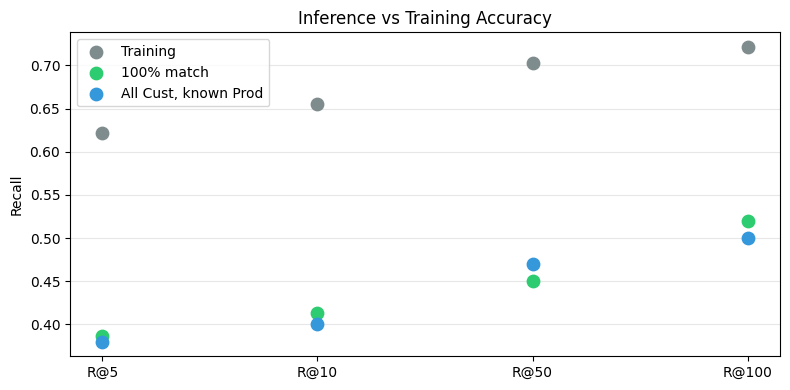

In [4]:
Ks = [5, 10, 50, 100]
labels = [f'R@{k}' for k in Ks]
x = np.arange(len(labels))

sources = [
    ('Training',             [TRAINING_RECALL[l] for l in labels], '#7f8c8d'),
    ('100% match',           [metrics_df[l].mean() for l in labels], '#2ecc71'),
    ('All Cust, known Prod', [metrics_prod_df[l].mean() for l in labels], '#3498db'),
]

fig, ax = plt.subplots(figsize=(8, 4))
for name, vals, color in sources:
    ax.scatter(x, vals, label=name, color=color, s=80, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Recall')
ax.set_title('Inference vs Training Accuracy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Daily Basket Coverage

  batch 1: 64 instances, 0.3s
  batch 2: 36 instances, 0.2s
Known Custms & Prods: 466 interactions, 100 baskets, 100 customers
  batch 1: 64 instances, 0.3s
  batch 2: 36 instances, 0.3s
All Custms, known Prods: 464 interactions, 100 baskets, 100 customers

Known Custms & Prods — basket sizes: min=1, median=3, max=13
  R@5 coverage: mean=0.1928
  R@10 coverage: mean=0.2072
  R@50 coverage: mean=0.2964
  R@100 coverage: mean=0.3530
  R@150 coverage: mean=0.4288

All Custms, known Prods — basket sizes: min=1, median=2, max=20
  R@5 coverage: mean=0.1608
  R@10 coverage: mean=0.1721
  R@50 coverage: mean=0.2889
  R@100 coverage: mean=0.3434
  R@150 coverage: mean=0.4231


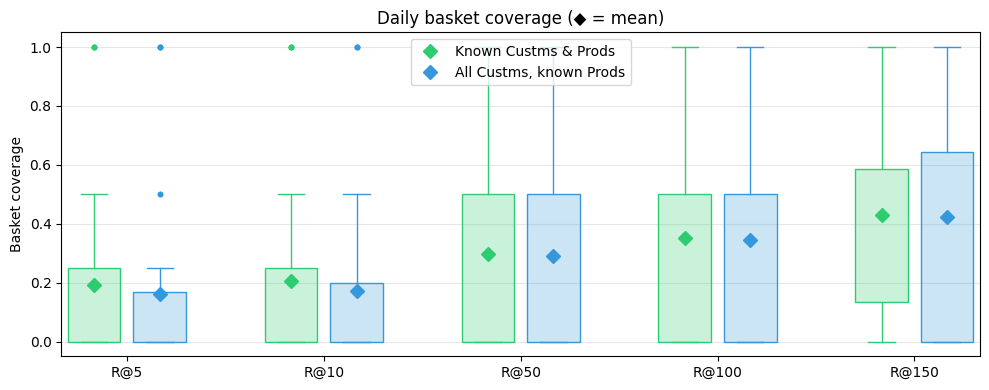

In [5]:
N_BASKET_CUSTS = 100
Ks = [5, 10, 50, 100, 150]

prod_str_b = ', '.join(str(p) for p in known_products)
cust_str_b = ', '.join(str(c) for c in known_customers)

def fetch_baskets(customer_filter):
    """Fetch and compute basket coverage via endpoint."""
    raw = client.query(f"""
    WITH eligible_customers AS (
        SELECT CAST(customer_id AS INT64) AS customer_id
        FROM `{BQ_TEST}`
        WHERE {customer_filter}
          AND product_id IN ({prod_str_b})
        GROUP BY customer_id
        ORDER BY RAND()
        LIMIT {N_BASKET_CUSTS}
    )
    SELECT
        CAST(t.customer_id AS INT64) AS customer_id,
        CAST(t.product_id AS INT64) AS product_id,
        t.cust_value,
        UNIX_SECONDS(t.date) AS date_unix,
        DATE(t.date) AS purchase_date,
        t.days_since_last_purchase,
        t.cust_order_days_60d,
        t.cust_unique_products_60d,
        t.purchase_history
    FROM `{BQ_TEST}` t
    JOIN eligible_customers e ON CAST(t.customer_id AS INT64) = e.customer_id
    WHERE t.product_id IN ({prod_str_b})
    """).to_dataframe()
    raw['days_since_last_purchase'] = raw['days_since_last_purchase'].fillna(0).astype(int)
    raw['cust_order_days_60d'] = raw['cust_order_days_60d'].fillna(0).astype(int)
    raw['cust_unique_products_60d'] = raw['cust_unique_products_60d'].fillna(0).astype(int)
    raw = raw.sort_values(['customer_id', 'purchase_date']).reset_index(drop=True)

    grouped = raw.groupby(['customer_id', 'purchase_date'])
    first_rows = raw.loc[grouped.cumcount() == 0].reset_index(drop=True)

    instances = build_instances(first_rows)
    rec_ids, _ = predict(instances)

    records = []
    for idx, ((cid, pdate), grp) in enumerate(grouped):
        basket_pids = set(grp['product_id'].values)
        recs = rec_ids[idx]
        row = {'customer_id': cid, 'date': pdate, 'basket_size': len(basket_pids)}
        for k in Ks:
            top_k = set(int(r) for r in recs[:k])
            row[f'R@{k}'] = len(basket_pids & top_k) / len(basket_pids)
        records.append(row)
    return pd.DataFrame(records), raw

basket_known, raw_known = fetch_baskets(f'customer_id IN ({cust_str_b})')
print(f'Known Custms & Prods: {len(raw_known)} interactions, {len(basket_known)} baskets, '
      f'{raw_known["customer_id"].nunique()} customers')

basket_all, raw_all = fetch_baskets('TRUE')
print(f'All Custms, known Prods: {len(raw_all)} interactions, {len(basket_all)} baskets, '
      f'{raw_all["customer_id"].nunique()} customers')

for label, df in [('Known Custms & Prods', basket_known), ('All Custms, known Prods', basket_all)]:
    print(f'\n{label} \u2014 basket sizes: min={df["basket_size"].min()}, '
          f'median={df["basket_size"].median():.0f}, max={df["basket_size"].max()}')
    for k in Ks:
        col = f'R@{k}'
        print(f'  {col} coverage: mean={df[col].mean():.4f}')

# Chart: side-by-side boxplots
labels = [f'R@{k}' for k in Ks]
n = len(labels)
positions_known = np.arange(n) * 3
positions_all = positions_known + 1

fig, ax = plt.subplots(figsize=(10, 4))

bp1 = ax.boxplot([basket_known[l] for l in labels], positions=positions_known, widths=0.8,
                  showmeans=True, meanline=False,
                  meanprops=dict(marker='D', markerfacecolor='#2ecc71', markeredgecolor='#2ecc71', markersize=7),
                  flierprops=dict(marker='o', markerfacecolor='#2ecc71', markeredgecolor='#2ecc71', markersize=3, alpha=0.5),
                  medianprops=dict(linewidth=0),
                  boxprops=dict(color='#2ecc71'), whiskerprops=dict(color='#2ecc71'), capprops=dict(color='#2ecc71'),
                  patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('#2ecc7140')

bp2 = ax.boxplot([basket_all[l] for l in labels], positions=positions_all, widths=0.8,
                  showmeans=True, meanline=False,
                  meanprops=dict(marker='D', markerfacecolor='#3498db', markeredgecolor='#3498db', markersize=7),
                  flierprops=dict(marker='o', markerfacecolor='#3498db', markeredgecolor='#3498db', markersize=3, alpha=0.5),
                  medianprops=dict(linewidth=0),
                  boxprops=dict(color='#3498db'), whiskerprops=dict(color='#3498db'), capprops=dict(color='#3498db'),
                  patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('#3498db40')

ax.set_xticks(positions_known + 0.5)
ax.set_xticklabels(labels)
ax.set_ylabel('Basket coverage')
ax.set_title('Daily basket coverage (\u25c6 = mean)')
ax.legend([bp1['means'][0], bp2['means'][0]], ['Known Custms & Prods', 'All Custms, known Prods'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Customer Basket vs Model Recommendations (re-run for a new customer)

In [28]:
cust_str_v = ', '.join(str(c) for c in known_customers)
prod_str_v = ', '.join(str(p) for p in known_products)

# Pick a random customer who has 1+ distinct products on one day
sample = client.query(f"""
WITH daily AS (
    SELECT CAST(customer_id AS INT64) AS customer_id, DATE(date) AS d,
           COUNT(DISTINCT product_id) AS n
    FROM `{BQ_TEST}`
    WHERE customer_id IN ({cust_str_v}) AND product_id IN ({prod_str_v})
    GROUP BY 1, 2
    HAVING n >= 1
)
SELECT customer_id, d FROM daily ORDER BY RAND() LIMIT 1
""").to_dataframe().iloc[0]

cid_v, day_v = int(sample['customer_id']), sample['d']

# Fetch what the customer actually bought that day (deduplicated)
bought = client.query(f"""
SELECT CAST(product_id AS INT64) AS product_id,
       ANY_VALUE(art_name) AS art_name,
       ANY_VALUE(stratbuy_domain_desc) AS category,
       ANY_VALUE(mge_main_cat_desc) AS sub_category,
       ANY_VALUE(cust_value) AS cust_value,
       ANY_VALUE(UNIX_SECONDS(date)) AS date_unix,
       ANY_VALUE(days_since_last_purchase) AS days_since_last_purchase,
       ANY_VALUE(cust_order_days_60d) AS cust_order_days_60d,
       ANY_VALUE(cust_unique_products_60d) AS cust_unique_products_60d,
       ANY_VALUE(purchase_history) AS purchase_history
FROM `{BQ_TEST}`
WHERE CAST(customer_id AS INT64) = {cid_v}
  AND DATE(date) = '{day_v}'
  AND product_id IN ({prod_str_v})
GROUP BY 1
""").to_dataframe()
bought['days_since_last_purchase'] = bought['days_since_last_purchase'].fillna(0).astype(int)
bought['cust_order_days_60d'] = bought['cust_order_days_60d'].fillna(0).astype(int)
bought['cust_unique_products_60d'] = bought['cust_unique_products_60d'].fillna(0).astype(int)

# Run inference for this customer via endpoint
row0 = bought.iloc[0]
instance = {
    'customer_id':  cid_v,
    'date':         int(row0['date_unix']),
    'cust_value':   float(row0['cust_value']),
    'cs_last_purch': int(row0['days_since_last_purchase']),
    'cs_orders':    int(row0['cust_order_days_60d']),
    'cs_unique_skus': int(row0['cust_unique_products_60d']),
    'history':      pad_history(row0['purchase_history']),
}
rec_ids_v, rec_scores_v = predict([instance])
raw_rec_pids = [int(p) for p in rec_ids_v[0]]
raw_rec_scores = rec_scores_v[0]

# Enrich product names + categories: test first, then fill gaps from train
all_str = ', '.join(str(p) for p in raw_rec_pids)
rec_meta = client.query(f"""
SELECT DISTINCT CAST(product_id AS INT64) AS product_id, art_name,
       stratbuy_domain_desc AS category, mge_main_cat_desc AS sub_category
FROM `{BQ_TEST}` WHERE product_id IN ({all_str})
""").to_dataframe().set_index('product_id').to_dict('index')

missing = [p for p in raw_rec_pids if p not in rec_meta]
if missing:
    miss_str = ', '.join(str(p) for p in missing)
    train_meta = client.query(f"""
    SELECT DISTINCT CAST(product_id AS INT64) AS product_id, art_name,
           stratbuy_domain_desc AS category, mge_main_cat_desc AS sub_category
    FROM `{BQ_TRAIN}` WHERE product_id IN ({miss_str})
    """).to_dataframe().set_index('product_id').to_dict('index')
    rec_meta.update(train_meta)

# Filter out suppressed products
rec_pids, rec_scores = [], []
for pid, score in zip(raw_rec_pids, raw_rec_scores):
    name = rec_meta.get(pid, {}).get('art_name', '')
    if name not in SUPPRESS_NAMES:
        rec_pids.append(pid)
        rec_scores.append(score)
rec_pids = rec_pids[:150]
rec_scores = rec_scores[:150]

bought_pids = set(bought['product_id'].values)
overlap = bought_pids & set(rec_pids)

# Customer info
display(HTML(f"""
<h3>Customer {cid_v} \u2014 {day_v} \u2014 cust_value {row0['cust_value']:.0f}</h3>
<p>Bought <b>{len(bought_pids)}</b> products &nbsp;|&nbsp;
   Top-150 recs overlap: <b>{len(overlap)}</b> ({len(overlap)/len(bought_pids)*100:.0f}%)
   &nbsp;|&nbsp; Suppressed: {SUPPRESS_NAMES or 'none'}</p>
"""))

# Styles
s = 'padding:4px 10px; border:1px solid #ccc;'
hs = f'{s} background:#eee;'
hit = f'{s} background:#d4edda;'

# Table 1: What the customer bought
bought_rows = ''
for _, r in bought.iterrows():
    pid = int(r['product_id'])
    rs = hit if pid in overlap else s
    bought_rows += (f'<tr><td style="{rs}">{r["art_name"]}</td>'
                    f'<td style="{rs}">{r["category"]}</td>'
                    f'<td style="{rs}">{r["sub_category"]}</td></tr>')

display(HTML(f"""
<b>Purchased ({len(bought_pids)} products)</b>
<table style="border-collapse:collapse; font-size:13px;">
<tr><th style="{hs}">Product</th><th style="{hs}">Category</th><th style="{hs}">Sub-category</th></tr>
{bought_rows}
</table>
"""))

# Table 2: Top-150 model recommendations
rec_rows = ''
for i, pid in enumerate(rec_pids):
    m = rec_meta.get(pid, {})
    name = m.get('art_name', f'({pid})')
    cat = m.get('category', '?')
    sub = m.get('sub_category', '?')
    rs = hit if pid in bought_pids else s
    rec_rows += (f'<tr><td style="{rs}">{i+1}</td><td style="{rs}">{name}</td>'
                 f'<td style="{rs}">{cat}</td><td style="{rs}">{sub}</td>'
                 f'<td style="{rs}">{rec_scores[i]:.2f}</td></tr>')

display(HTML(f"""
<b>Model Top-150 Recommendations</b>
<table style="border-collapse:collapse; font-size:13px;">
<tr><th style="{hs}">#</th><th style="{hs}">Product</th><th style="{hs}">Category</th><th style="{hs}">Sub-category</th><th style="{hs}">Score</th></tr>
{rec_rows}
</table>
"""))


Product,Category,Sub-category
"JAMESON ВІСКІ 0,7",SPIRITS,ВІСКІ
MC СЬОМГА ШМАТ Х/К300,FRESH FISH,ІНШІ КОПЧЕНА РИБА
DISAS ІКРА ФОРЕЛІ 400Г,FRESH FISH,РИБНІ ДЕЛІКАТЕСИ
MPRO ПАКЕТ МАЛ 51МКМ 40*60,DISPOSABLES & TABLEWARE,СУМКИ ДЛЯ ПОКУПОК


#,Product,Category,Sub-category,Score
1,BOUNTY БАТОНЧИК З КОКОС 57Г,CONFECTIONERY & SNACKS,ШОКОЛАД,615.19
2,"МОРШИНСЬКА ВОДА НЕГАЗ. 1,5Л",NON ALCOHOLIC DRINKS,ВОДИ,613.79
3,MC НАГЕТСИ КУРЯЧІ 1КГ,DEEP FROZEN,ЗАМОРОЖЕНА ГОТОВА ЇЖА,608.89
4,БАРНІ БІСКВІТ МОЛ 150Г,CONFECTIONERY & SNACKS,СОЛОДКЕ ПЕЧИВО/ КЕКСИ,605.48
5,ТОРЧИН МАЙОН ЄВРОПЕЙС ДП 520Г,DAIRY,МАРГАРИН,605.33
6,ПОЛЯНА КВАСОВА ВОДА МІНЕРАЛЬНА 1.5Л,NON ALCOHOLIC DRINKS,ВОДИ,604.35
7,SNICKERS ШОК БАТ 50Г,CONFECTIONERY & SNACKS,ШОКОЛАД,592.32
8,"САДОЧОК НЕКТАР НЕКТАР МУЛЬТИФРУКТ. 0,2 Л",NON ALCOHOLIC DRINKS,СОКИ/ НЕГАЗОВАНІ НАПОЇ,590.92
9,CORONA EXTRA ПИВО 0.33Л,BEERS,ЛАГЕР/ ПІЛЬЗНЕР,590.07
10,"COCA-COLA НАП Ж/Б 0,33Л",NON ALCOHOLIC DRINKS,ГАЗОВАНІ БЕЗАЛКОГОЛЬНІ НАПОЇ,586.13
